C:\Users\acer\AppData\Local\Temp\ipykernel_7052\3810930666.py:33: FutureWarning: The provided callable <function sum at 0x0000018BFFD7E820> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  inc_exp_pivot = pd.pivot_table(inc_exp,


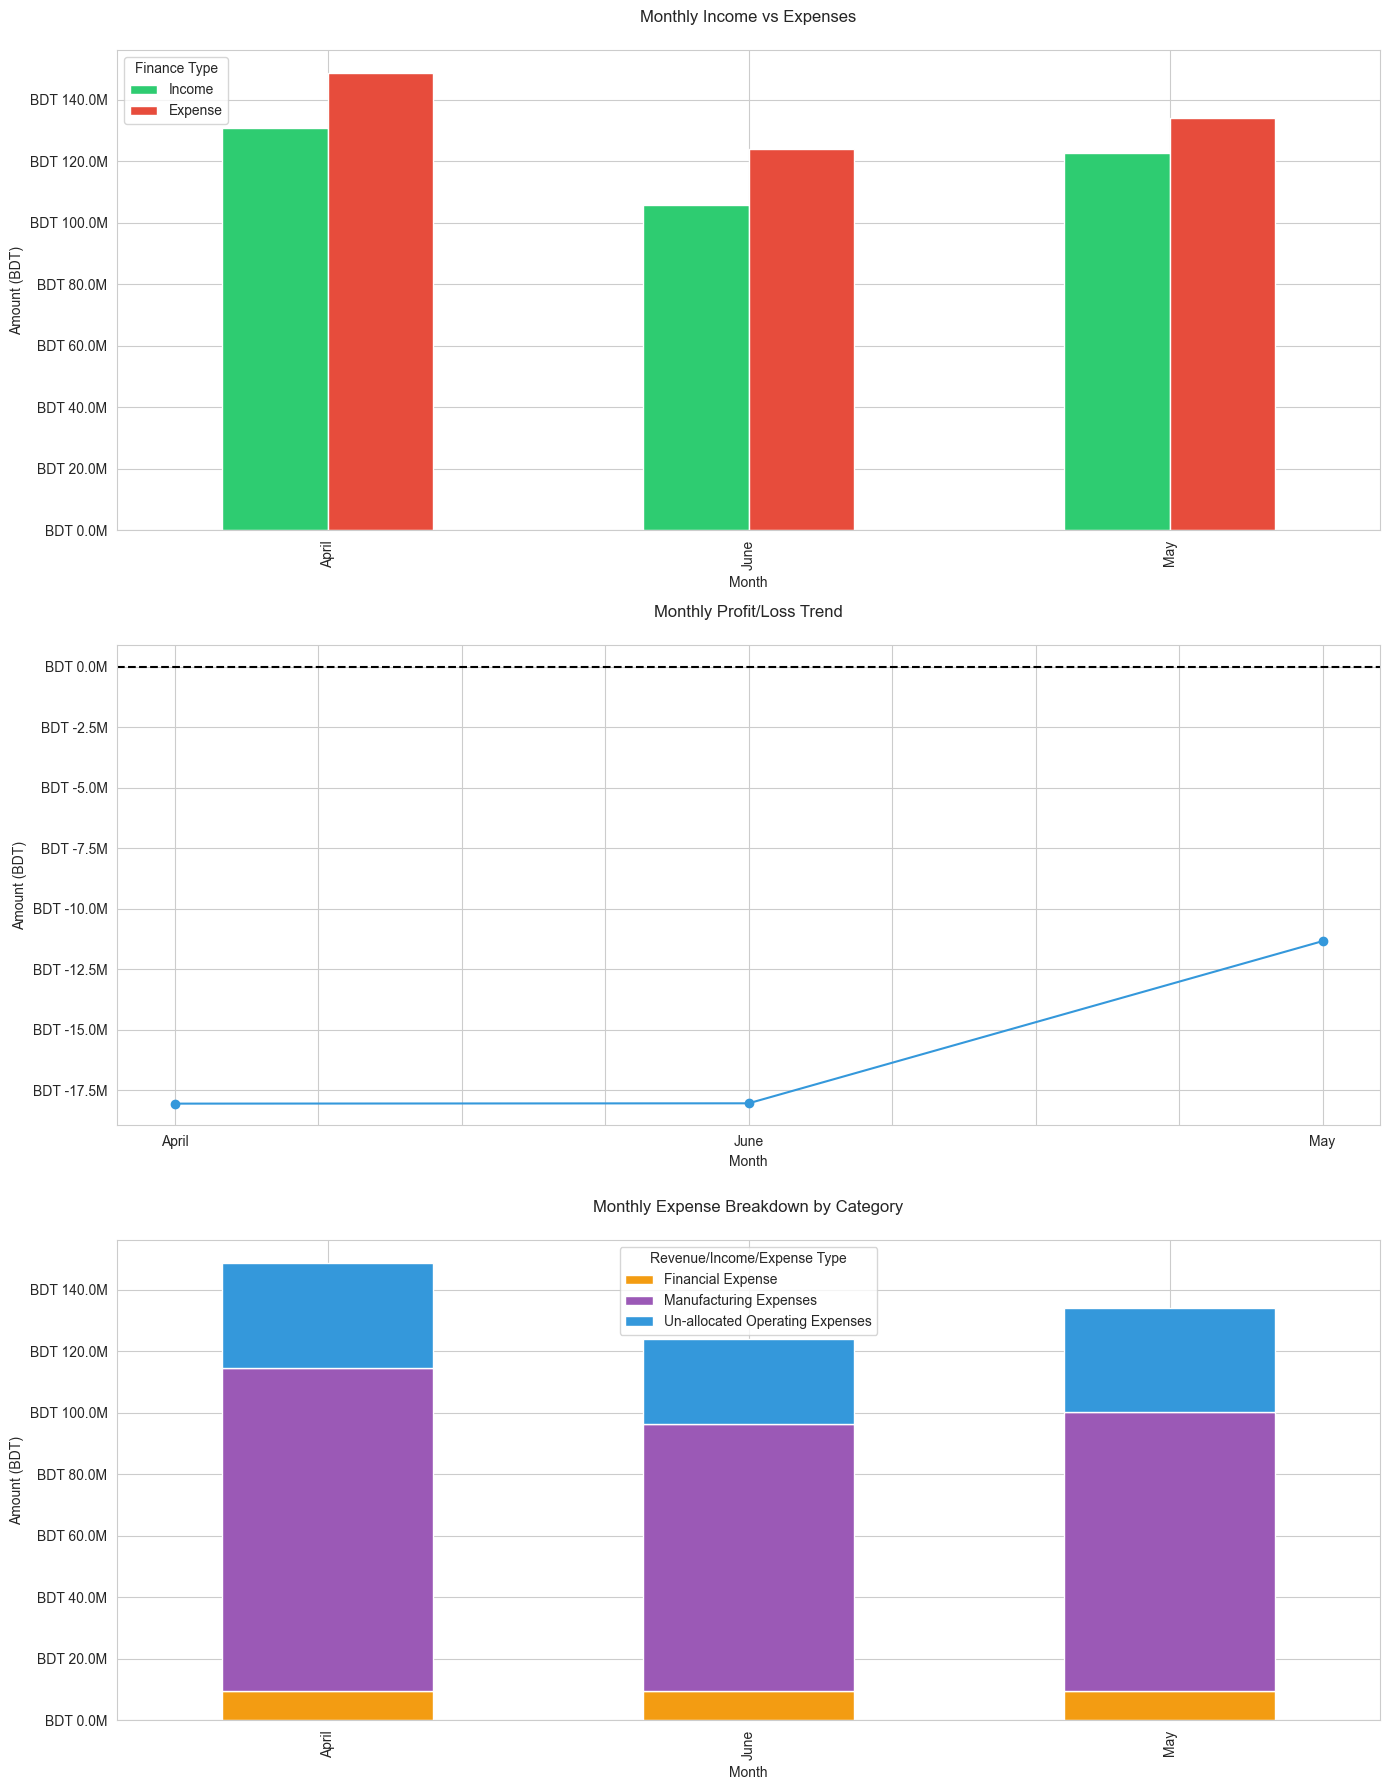

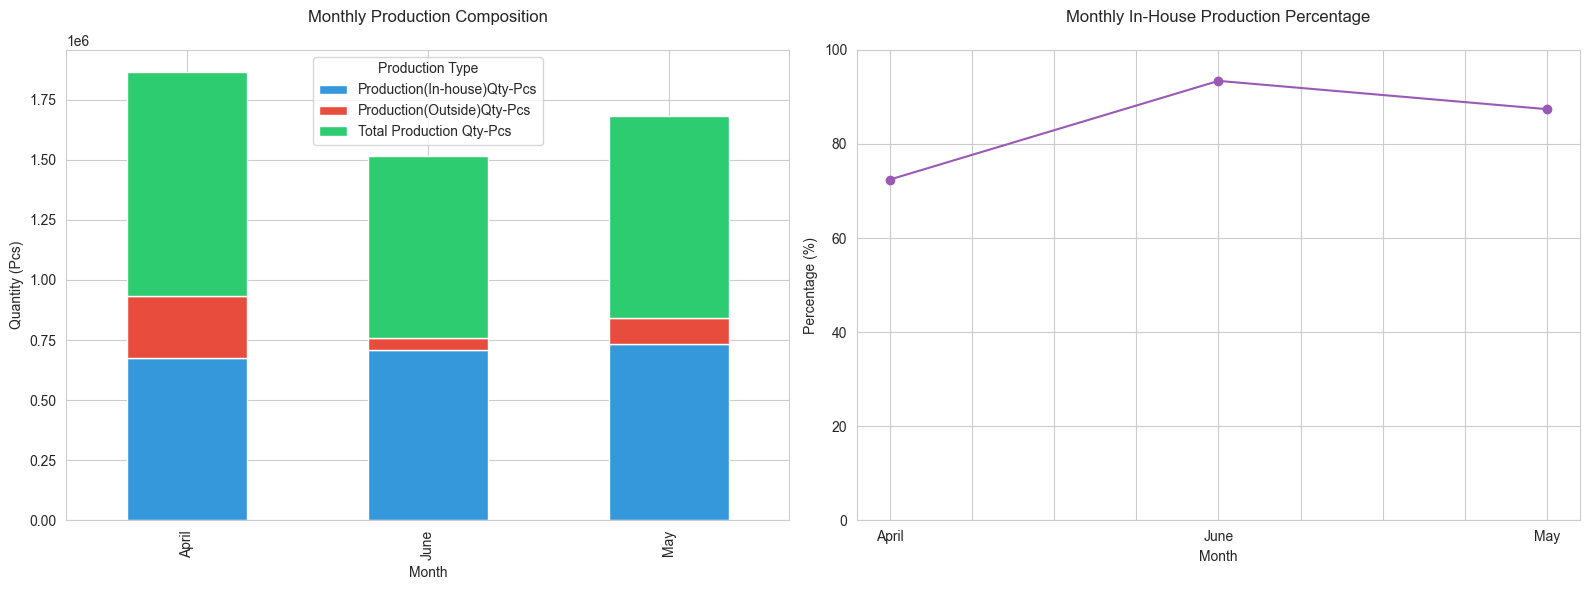

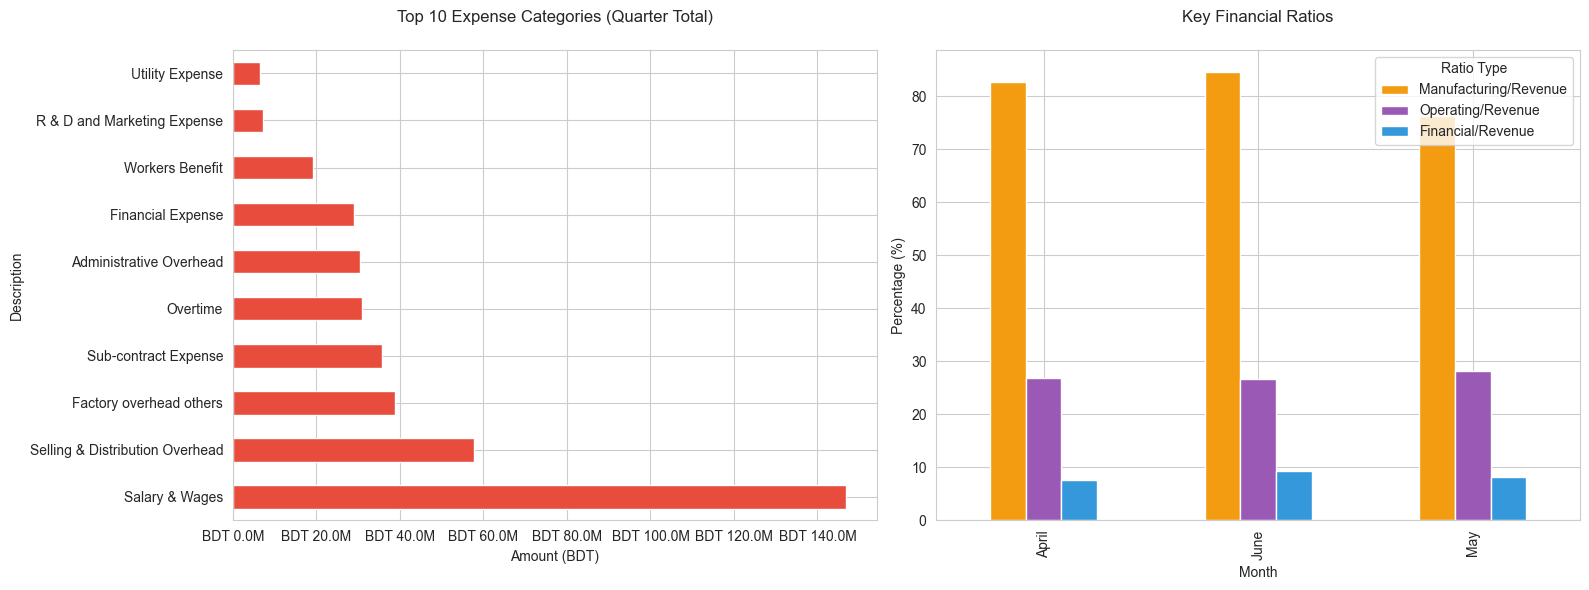


=== COMPREHENSIVE FINANCIAL ANALYSIS ===

1. Monthly Financial Summary:
Finance Type             Expense              Income         Profit/Loss
Month                                                                   
April         BDT 148,855,099.20  BDT 130,800,985.54  BDT -18,054,113.66
June          BDT 123,985,620.47  BDT 105,944,544.01  BDT -18,041,076.46
May           BDT 134,150,237.61  BDT 122,810,861.70  BDT -11,339,375.90

2. Expense Breakdown by Category:
Revenue/Income/Expense Type Financial Expense Manufacturing Expenses  \
Month                                                                  
April                        BDT 9,660,000.00     BDT 105,124,414.98   
June                         BDT 9,660,000.00      BDT 86,867,265.40   
May                          BDT 9,660,000.00      BDT 90,807,871.92   

Revenue/Income/Expense Type Un-allocated Operating Expenses  
Month                                                        
April                                     

C:\Users\acer\AppData\Local\Temp\ipykernel_7052\3810930666.py:172: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(financial_summary.applymap(lambda x: f"BDT {x:,.2f}"))
C:\Users\acer\AppData\Local\Temp\ipykernel_7052\3810930666.py:175: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(expense_breakdown.applymap(lambda x: f"BDT {x:,.2f}"))
C:\Users\acer\AppData\Local\Temp\ipykernel_7052\3810930666.py:178: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(revenue_breakdown.applymap(lambda x: f"BDT {x:,.2f}"))
C:\Users\acer\AppData\Local\Temp\ipykernel_7052\3810930666.py:181: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(ratios.applymap(lambda x: f"{x:.1f}%"))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Load the Excel file
file_path = 'SKDL-2nd Quarter budget(1).xlsx'
inc_exp = pd.read_excel(file_path, sheet_name='Inc_exp')
summary = pd.read_excel(file_path, sheet_name='summary', skiprows=3)

# --------------------------------------
# 1. Enhanced Data Cleaning
# --------------------------------------

def clean_amount(x):
    if isinstance(x, str):
        x = x.replace(',', '').replace(')', '')
        if '(' in x:
            return -float(x.replace('(', ''))
    return float(x)

inc_exp['Amount'] = inc_exp['Amount'].apply(clean_amount)
summary.columns = ['Ignore1', 'Ignore2', 'Particular', 'Month', 'Amount']
summary = summary[['Particular', 'Month', 'Amount']]
summary['Amount'] = summary['Amount'].apply(clean_amount)

# --------------------------------------
# 2. Comprehensive Financial Analysis
# --------------------------------------

# Create pivot tables for detailed analysis
inc_exp_pivot = pd.pivot_table(inc_exp, 
                              values='Amount', 
                              index=['Month', 'Finance Type', 'Revenue/Income/Expense Type', 'Description'],
                              aggfunc=np.sum).reset_index()

# Monthly financial performance summary
financial_summary = inc_exp_pivot.groupby(['Month', 'Finance Type'])['Amount'].sum().unstack()
financial_summary['Profit/Loss'] = financial_summary['Income'] - financial_summary['Expense']

# Expense category breakdown
expense_breakdown = inc_exp_pivot[inc_exp_pivot['Finance Type'] == 'Expense'].groupby(
    ['Month', 'Revenue/Income/Expense Type'])['Amount'].sum().unstack()

# Revenue category breakdown
revenue_breakdown = inc_exp_pivot[inc_exp_pivot['Finance Type'] == 'Income'].groupby(
    ['Month', 'Revenue/Income/Expense Type'])['Amount'].sum().unstack()

# --------------------------------------
# 3. Production Efficiency Analysis
# --------------------------------------

# Extract production data from summary
production_data = summary[summary['Particular'].str.contains('Production', na=False)]
production_pivot = production_data.pivot(index='Particular', columns='Month', values='Amount')

# Calculate in-house production percentage
inhouse_pct = (production_pivot.loc['Production(In-house)Qty-Pcs'] / 
               production_pivot.loc['Total Production Qty-Pcs']) * 100

# --------------------------------------
# 4. Expense-to-Revenue Ratios
# --------------------------------------

# Calculate key ratios
ratios = pd.DataFrame()
ratios['Manufacturing/Revenue'] = (expense_breakdown['Manufacturing Expenses'] / 
                                  revenue_breakdown['Operating Revenue']) * 100
ratios['Operating/Revenue'] = (expense_breakdown['Un-allocated Operating Expenses'] / 
                              revenue_breakdown['Operating Revenue']) * 100
ratios['Financial/Revenue'] = (expense_breakdown['Financial Expense'] / 
                             revenue_breakdown['Operating Revenue']) * 100

# --------------------------------------
# 5. Trend Analysis
# --------------------------------------

# Calculate month-over-month changes
def calculate_mom_change(df):
    return df.pct_change() * 100

revenue_trend = calculate_mom_change(revenue_breakdown['Operating Revenue'])
expense_trend = calculate_mom_change(expense_breakdown['Manufacturing Expenses'])
profit_trend = calculate_mom_change(financial_summary['Profit/Loss'])

# --------------------------------------
# 6. Advanced Visualizations
# --------------------------------------

# Custom formatter for currency
def currency_formatter(x, pos):
    return f"BDT {x/1e6:,.1f}M"

currency_format = FuncFormatter(currency_formatter)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 6.1 Financial Performance Dashboard
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18))

# Income vs Expense
financial_summary[['Income', 'Expense']].plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.yaxis.set_major_formatter(currency_format)
ax1.set_title('Monthly Income vs Expenses', pad=20)
ax1.set_ylabel('Amount (BDT)')

# Profit/Loss trend
financial_summary['Profit/Loss'].plot(kind='line', marker='o', ax=ax2, color='#3498db')
ax2.axhline(0, color='black', linestyle='--')
ax2.yaxis.set_major_formatter(currency_format)
ax2.set_title('Monthly Profit/Loss Trend', pad=20)
ax2.set_ylabel('Amount (BDT)')

# Expense breakdown
expense_breakdown.plot(kind='bar', stacked=True, ax=ax3, 
                      color=['#f39c12', '#9b59b6', '#3498db', '#1abc9c'])
ax3.yaxis.set_major_formatter(currency_format)
ax3.set_title('Monthly Expense Breakdown by Category', pad=20)
ax3.set_ylabel('Amount (BDT)')

plt.tight_layout()
plt.show()

# 6.2 Production Analysis Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Production composition
production_pivot.T.plot(kind='bar', stacked=True, ax=ax1, 
                       color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_title('Monthly Production Composition', pad=20)
ax1.set_ylabel('Quantity (Pcs)')
ax1.legend(title='Production Type')

# In-house production percentage
inhouse_pct.plot(kind='line', marker='o', ax=ax2, color='#9b59b6')
ax2.set_title('Monthly In-House Production Percentage', pad=20)
ax2.set_ylabel('Percentage (%)')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 6.3 Expense Analysis Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 expenses across all months
top_expenses = inc_exp[inc_exp['Finance Type'] == 'Expense'].groupby(
    'Description')['Amount'].sum().nlargest(10)
top_expenses.plot(kind='barh', ax=ax1, color='#e74c3c')
ax1.xaxis.set_major_formatter(currency_format)
ax1.set_title('Top 10 Expense Categories (Quarter Total)', pad=20)
ax1.set_xlabel('Amount (BDT)')

# Expense-to-revenue ratios
ratios.plot(kind='bar', ax=ax2, color=['#f39c12', '#9b59b6', '#3498db'])
ax2.set_title('Key Financial Ratios', pad=20)
ax2.set_ylabel('Percentage (%)')
ax2.legend(title='Ratio Type')

plt.tight_layout()
plt.show()

# --------------------------------------
# 7. Detailed Reporting
# --------------------------------------

print("\n=== COMPREHENSIVE FINANCIAL ANALYSIS ===")
print("\n1. Monthly Financial Summary:")
print(financial_summary.applymap(lambda x: f"BDT {x:,.2f}"))

print("\n2. Expense Breakdown by Category:")
print(expense_breakdown.applymap(lambda x: f"BDT {x:,.2f}"))

print("\n3. Revenue Breakdown by Category:")
print(revenue_breakdown.applymap(lambda x: f"BDT {x:,.2f}"))

print("\n4. Key Financial Ratios (% of Revenue):")
print(ratios.applymap(lambda x: f"{x:.1f}%"))

print("\n5. Production Efficiency Metrics:")
print(f"In-house Production %:\n{inhouse_pct.apply(lambda x: f'{x:.1f}%')}")

print("\n6. Month-over-Month Trends:")
print(f"Revenue Change: {revenue_trend.iloc[-1]:.1f}%")
print(f"Expense Change: {expense_trend.iloc[-1]:.1f}%")
print(f"Profit Change: {profit_trend.iloc[-1]:.1f}%")

# --------------------------------------
# 8. Export Analysis Results
# --------------------------------------

# Create Excel writer
with pd.ExcelWriter('SKDL_Deep_Analysis_Results.xlsx') as writer:
    financial_summary.to_excel(writer, sheet_name='Financial Summary')
    expense_breakdown.to_excel(writer, sheet_name='Expense Breakdown')
    revenue_breakdown.to_excel(writer, sheet_name='Revenue Breakdown')
    ratios.to_excel(writer, sheet_name='Financial Ratios')
    production_pivot.to_excel(writer, sheet_name='Production Data')
    pd.DataFrame(inhouse_pct).to_excel(writer, sheet_name='In-House %')

print("\nAnalysis results exported to 'SKDL_Deep_Analysis_Results.xlsx'")

In [3]:
from matplotlib.backends.backend_pdf import PdfPages

# Create a PdfPages object
with PdfPages('SKDL_Deep_Analysis_Report.pdf') as pdf:
    
    # 6.1 Financial Performance Dashboard
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18))
    financial_summary[['Income', 'Expense']].plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
    ax1.yaxis.set_major_formatter(currency_format)
    ax1.set_title('Monthly Income vs Expenses', pad=20)
    ax1.set_ylabel('Amount (BDT)')
    
    financial_summary['Profit/Loss'].plot(kind='line', marker='o', ax=ax2, color='#3498db')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.yaxis.set_major_formatter(currency_format)
    ax2.set_title('Monthly Profit/Loss Trend', pad=20)
    ax2.set_ylabel('Amount (BDT)')
    
    expense_breakdown.plot(kind='bar', stacked=True, ax=ax3, 
                          color=['#f39c12', '#9b59b6', '#3498db', '#1abc9c'])
    ax3.yaxis.set_major_formatter(currency_format)
    ax3.set_title('Monthly Expense Breakdown by Category', pad=20)
    ax3.set_ylabel('Amount (BDT)')
    
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6.2 Production Analysis Dashboard
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    production_pivot.T.plot(kind='bar', stacked=True, ax=ax1, 
                           color=['#3498db', '#e74c3c', '#2ecc71'])
    ax1.set_title('Monthly Production Composition', pad=20)
    ax1.set_ylabel('Quantity (Pcs)')
    ax1.legend(title='Production Type')

    inhouse_pct.plot(kind='line', marker='o', ax=ax2, color='#9b59b6')
    ax2.set_title('Monthly In-House Production Percentage', pad=20)
    ax2.set_ylabel('Percentage (%)')
    ax2.set_ylim(0, 100)

    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 6.3 Expense Analysis Dashboard
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    top_expenses.plot(kind='barh', ax=ax1, color='#e74c3c')
    ax1.xaxis.set_major_formatter(currency_format)
    ax1.set_title('Top 10 Expense Categories (Quarter Total)', pad=20)
    ax1.set_xlabel('Amount (BDT)')

    ratios.plot(kind='bar', ax=ax2, color=['#f39c12', '#9b59b6', '#3498db'])
    ax2.set_title('Key Financial Ratios', pad=20)
    ax2.set_ylabel('Percentage (%)')
    ax2.legend(title='Ratio Type')

    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # Now, export tables as images in the PDF
    def render_mpl_table(data, col_width=4.0, row_height=0.625, font_size=14,
                         header_color='#40466e', row_colors=['#f1f1f2', 'w'], edge_color='w',
                         bbox=[0, 0, 1, 1], header_columns=0,
                         ax=None, **kwargs):
        if ax is None:
            size = (np.array(data.shape[::-1]) + np.array([0, 1])) * np.array([col_width, row_height])
            fig, ax = plt.subplots(figsize=size)
            ax.axis('off')

        mpl_table = ax.table(cellText=data.values, bbox=bbox, colLabels=data.columns, rowLabels=data.index, **kwargs)

        mpl_table.auto_set_font_size(False)
        mpl_table.set_fontsize(font_size)

        for k, cell in mpl_table._cells.items():
            cell.set_edgecolor(edge_color)
            if k[0] == 0 or k[1] < header_columns:
                cell.set_text_props(weight='bold', color='w')
                cell.set_facecolor(header_color)
            else:
                cell.set_facecolor(row_colors[k[0] % len(row_colors)])
        return ax

    tables = [
        (financial_summary, "Monthly Financial Summary"),
        (expense_breakdown, "Expense Breakdown by Category"),
        (revenue_breakdown, "Revenue Breakdown by Category"),
        (ratios, "Key Financial Ratios"),
        (pd.DataFrame(inhouse_pct, columns=['In-house %']), "In-house Production Percentage"),
    ]

    for df, title in tables:
        fig, ax = plt.subplots(figsize=(20, 8))
        plt.title(title, fontsize=16, pad=20)
        render_mpl_table(df.round(2), ax=ax)
        pdf.savefig()
        plt.close()
